In [77]:
# Path to your benchmark CSVs
from pathlib import Path

DATAFOLDER = Path("../data/2026-01-12T00:39:10/csv").resolve()
DATAFOLDER

PosixPath('/home/tobiasponeschtu/Documents/AMP_Project/project_skeleton/data/2026-01-12T00:39:10/csv')

In [78]:
# Imports + plotting defaults
import re
import math
from dataclasses import dataclass
from typing import Optional
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# sanity check
csv_files = sorted(DATAFOLDER.glob("*.csv"))
print("CSV files:", len(csv_files))
print("Example:", csv_files[0].name if csv_files else "<none>")

CSV files: 196
Example: ex1_seq_p1_b1000_s1_r10.csv


In [79]:
# Loading + parsing utilities
FILENAME_RE = re.compile(
    r"^ex(?P<exercise>\d+)_(?P<variant>[a-z]+)_p(?P<p>\d+)_b(?P<b>\d+)_s(?P<s>\d+)_r(?P<r>\d+)\.csv$"
    r"|^ex(?P<exercise2>\d+)_seq_p(?P<p2>\d+)_b(?P<b2>\d+)_s(?P<s2>\d+)_r(?P<r2>\d+)\.csv$"
    r"$",
    flags=re.IGNORECASE,
 )


def parse_filename(path: Path) -> dict:
    """Parse metadata from a benchmark CSV filename.

    Supported examples:
      - ex4_d_p64_b1000_s1_r10.csv
      - ex5_a_p8_b1_s1_r10.csv
      - ex1_seq_p1_b1_s5_r10.csv
    """
    name = path.name
    m = FILENAME_RE.match(name)
    if not m:
        raise ValueError(f"Unrecognized filename format: {name}")
    g = m.groupdict()
    if g.get("exercise") is not None:
        # ex{exercise}_{variant}_...
        exercise = int(g["exercise"])
        variant = g["variant"].lower()
        p = int(g["p"])
        b = int(g["b"])
        s = int(g["s"])
        r = int(g["r"])
        mode = "concurrent"
    else:
        # ex{exercise}_seq_...
        exercise = int(g["exercise2"])
        variant = "seq"
        p = int(g["p2"])
        b = int(g["b2"])
        s = int(g["s2"])
        r = int(g["r2"])
        mode = "sequential"
    return {
        "file": name,
        "exercise": exercise,
        "variant": variant,   # a/b/c/d or seq
        "p_from_name": p,
        "batch": b,
        "s": s,
        "r_from_name": r,
        "mode": mode,
    }


def infer_impl(exercise: int, variant: str) -> str:
    """Human-friendly implementation label for plots.

    Adjust mapping if your report uses different naming.
    """
    if exercise == 1 and variant == "seq":
        return "seq"
    if exercise == 4:
        return "ex4"
    if exercise == 5:
        return "ex5"
    if exercise == 2:
        return "ex2"
    return f"ex{exercise}_{variant}"


def load_one_csv(path: Path) -> pd.DataFrame:
    meta = parse_filename(path)
    df = pd.read_csv(path)

    # Ensure expected numeric columns exist (some experiments may omit some cols).
    expected_cols = [
        "Repetition","NumThreads","TimeInterval","ActualBenchTime","ThreadID",
        "NrEnqOps","NrDeqOps",
        "NrFailedEnqOps","NrFailedDeqOps",
        "NrFailedEnqCASOps","NrFailedDeqCASOps",
        "NrFreeListInsertions","MaxFreeListSize",
    ]
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} missing columns: {missing}")

    # Normalize dtypes (keep it simple and robust).
    for c in expected_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["exercise"] = meta["exercise"]
    df["variant"] = meta["variant"]
    df["impl"] = infer_impl(meta["exercise"], meta["variant"])
    df["batch"] = meta["batch"]
    df["s"] = meta["s"]
    df["r_from_name"] = meta["r_from_name"]
    df["file"] = meta["file"]
    return df


def load_all_csvs(folder: Path = DATAFOLDER) -> pd.DataFrame:
    paths = sorted(folder.glob("*.csv"))
    if not paths:
        raise FileNotFoundError(f"No CSVs found under: {folder}")
    parts = [load_one_csv(p) for p in paths]
    return pd.concat(parts, ignore_index=True)


raw = load_all_csvs(DATAFOLDER)
raw.head()

ValueError: ex1_seq_p1_b1000_s1_r10.csv missing columns: ['ActualBenchTime']

In [ ]:
# Aggregation helpers (per-run metrics)
def per_run_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate raw per-thread rows into per-repetition metrics per file."""
    group_cols = ["file","exercise","variant","impl","batch","s","Repetition","NumThreads"]
    g = df.groupby(group_cols, dropna=False)

    # time interval is per row; use first non-null
    out = g.agg(
        TimeInterval_s=("TimeInterval","first"),
        ActualBenchTime_s=("ActualBenchTime","mean"),
        total_enq=("NrEnqOps","sum"),
        total_deq=("NrDeqOps","sum"),
        total_failed_enq=("NrFailedEnqOps","sum"),
        total_failed_deq=("NrFailedDeqOps","sum"),
        total_failed_enq_cas=("NrFailedEnqCASOps","sum"),
        total_failed_deq_cas=("NrFailedDeqCASOps","sum"),
        freelist_insertions=("NrFreeListInsertions","sum"),
        max_freelist_size_global=("MaxFreeListSize","max"),
    ).reset_index()

    out["total_ops"] = out["total_enq"] + out["total_deq"]
    out["throughput_ops_s"] = out["total_ops"] / out["TimeInterval_s"]
    out["freelist_inserts_s"] = out["freelist_insertions"] / out["TimeInterval_s"]

    # CAS-failure ratios (avoid divide-by-zero)
    denom = out["total_ops"].replace(0, pd.NA)
    out["failed_cas_per_op"] = (out["total_failed_enq_cas"] + out["total_failed_deq_cas"]) / denom
    out["failed_enq_cas_per_op"] = out["total_failed_enq_cas"] / denom
    out["failed_deq_cas_per_op"] = out["total_failed_deq_cas"] / denom

    return out

run_df = per_run_metrics(raw)
run_df.head()

,file,exercise,variant,impl,batch,s,Repetition,NumThreads,TimeInterval_s,total_enq,...,total_failed_enq_cas,total_failed_deq_cas,freelist_insertions,max_freelist_size_global,total_ops,throughput_ops_s,freelist_inserts_s,failed_cas_per_op,failed_enq_cas_per_op,failed_deq_cas_per_op
0,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,1,1,1,116219000,...,0,0,116219000,1000,232438000,232438000.0,116219000.0,0.0,0.0,0.0
1,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,2,1,1,115602000,...,0,0,115602000,1000,231204000,231204000.0,115602000.0,0.0,0.0,0.0
2,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,3,1,1,116055000,...,0,0,116055000,1000,232110000,232110000.0,116055000.0,0.0,0.0,0.0
3,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,4,1,1,116133000,...,0,0,116133000,1000,232266000,232266000.0,116133000.0,0.0,0.0,0.0
4,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,5,1,1,115891000,...,0,0,115891000,1000,231782000,231782000.0,115891000.0,0.0,0.0,0.0


In [ ]:
run_df[]

,file,exercise,variant,impl,batch,s,Repetition,NumThreads,TimeInterval_s,total_enq,...,total_failed_enq_cas,total_failed_deq_cas,freelist_insertions,max_freelist_size_global,total_ops,throughput_ops_s,freelist_inserts_s,failed_cas_per_op,failed_enq_cas_per_op,failed_deq_cas_per_op
0,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,1,1,1,116219000,...,0,0,116219000,1000,232438000,232438000.0,116219000.0,0.0,0.0,0.0
1,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,2,1,1,115602000,...,0,0,115602000,1000,231204000,231204000.0,115602000.0,0.0,0.0,0.0
2,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,3,1,1,116055000,...,0,0,116055000,1000,232110000,232110000.0,116055000.0,0.0,0.0,0.0
3,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,4,1,1,116133000,...,0,0,116133000,1000,232266000,232266000.0,116133000.0,0.0,0.0,0.0
4,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,5,1,1,115891000,...,0,0,115891000,1000,231782000,231782000.0,115891000.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955,ex5_d_p8_b1_s1_r10.csv,5,d,ex5,1,1,6,8,1,492859,...,419489,11949,104330,26488,597189,597189.0,104330.0,0.722448,0.702439,0.020009
1956,ex5_d_p8_b1_s1_r10.csv,5,d,ex5,1,1,7,8,1,461999,...,466744,11723,99280,25338,561279,561279.0,99280.0,0.852458,0.831572,0.020886
1957,ex5_d_p8_b1_s1_r10.csv,5,d,ex5,1,1,8,8,1,489179,...,509776,11300,107082,27103,596261,596261.0,107082.0,0.873906,0.854954,0.018951
1958,ex5_d_p8_b1_s1_r10.csv,5,d,ex5,1,1,9,8,1,478437,...,483352,11156,104738,26631,583175,583175.0,104738.0,0.847958,0.828828,0.01913


## Plots dev

### a Plot sequential throughputs

In [7]:
seq = run_df[run_df["impl"] == "seq"]

In [8]:
def plot_seq_throughput(seq_df: pd.DataFrame):
    """Barplot showing throughput of sequential implementation for 1s and 5s runs, for each batch size."""
    # Prepare data
    batches = sorted(seq_df['batch'].unique())
    durations = sorted(seq_df['s'].unique())
    width = 0.35  # width of the bars

    fig, ax = plt.subplots(figsize=(6, 4))

    for i, s_val in enumerate(durations):
        means = []
        stds = []
        for b in batches:
            vals = seq_df[(seq_df['batch'] == b) & (seq_df['s'] == s_val)]['throughput_ops_s']
            means.append(vals.mean())
            stds.append(vals.std())
        x = [j + i * width for j in range(len(batches))]
        ax.bar(x, means, width=width, yerr=stds, label=f"{s_val}s", alpha=0.8)

    ax.set_title("Sequential Implementation Throughput")
    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Throughput (ops/s)")
    # ax.set_yscale("log")
    ax.set_xticks([r + width / 2 for r in range(len(batches))])
    ax.set_xticklabels(batches)
    ax.legend(title="Run Duration (s)")
    plt.tight_layout()
    plt.show()
    

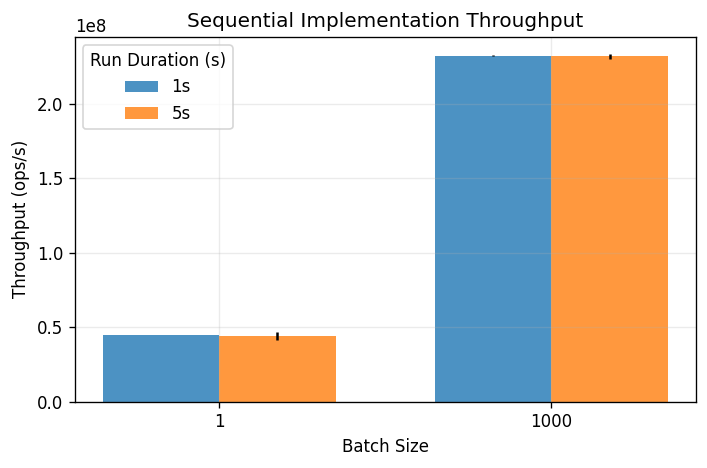

In [9]:
plot_seq_throughput(seq)

In [10]:
#average over repetitions
run_df[run_df["impl"] == "seq"].groupby(
    ["batch","s"]
)["throughput_ops_s"].agg(["mean","std"]).reset_index()

,batch,s,mean,std
0,1,1,4.492289e+07,2.508422e+04
1,1,5,4.402407e+07,2.833333e+06
2,1000,1,2.321592e+08,4.385666e+05
3,1000,5,2.315541e+08,1.426423e+06


In [28]:
seq

,file,exercise,variant,impl,batch,s,Repetition,NumThreads,TimeInterval_s,total_enq,...,total_failed_enq_cas,total_failed_deq_cas,freelist_insertions,max_freelist_size_global,total_ops,throughput_ops_s,freelist_inserts_s,failed_cas_per_op,failed_enq_cas_per_op,failed_deq_cas_per_op
0,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,1,1,1,116219000,...,0,0,116219000,1000,232438000,232438000.0,116219000.0,0.0,0.0,0.0
1,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,2,1,1,115602000,...,0,0,115602000,1000,231204000,231204000.0,115602000.0,0.0,0.0,0.0
2,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,3,1,1,116055000,...,0,0,116055000,1000,232110000,232110000.0,116055000.0,0.0,0.0,0.0
3,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,4,1,1,116133000,...,0,0,116133000,1000,232266000,232266000.0,116133000.0,0.0,0.0,0.0
4,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,5,1,1,115891000,...,0,0,115891000,1000,231782000,231782000.0,115891000.0,0.0,0.0,0.0
5,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,6,1,1,116287000,...,0,0,116287000,1000,232574000,232574000.0,116287000.0,0.0,0.0,0.0
6,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,7,1,1,116383000,...,0,0,116383000,1000,232766000,232766000.0,116383000.0,0.0,0.0,0.0
7,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,8,1,1,116142000,...,0,0,116142000,1000,232284000,232284000.0,116142000.0,0.0,0.0,0.0
8,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,9,1,1,116089000,...,0,0,116089000,1000,232178000,232178000.0,116089000.0,0.0,0.0,0.0
9,ex1_seq_p1_b1000_s1_r10.csv,1,seq,seq,1000,1,10,1,1,115995000,...,0,0,115995000,1000,231990000,231990000.0,115995000.0,0.0,0.0,0.0


### b Total throughput vs nr of threads

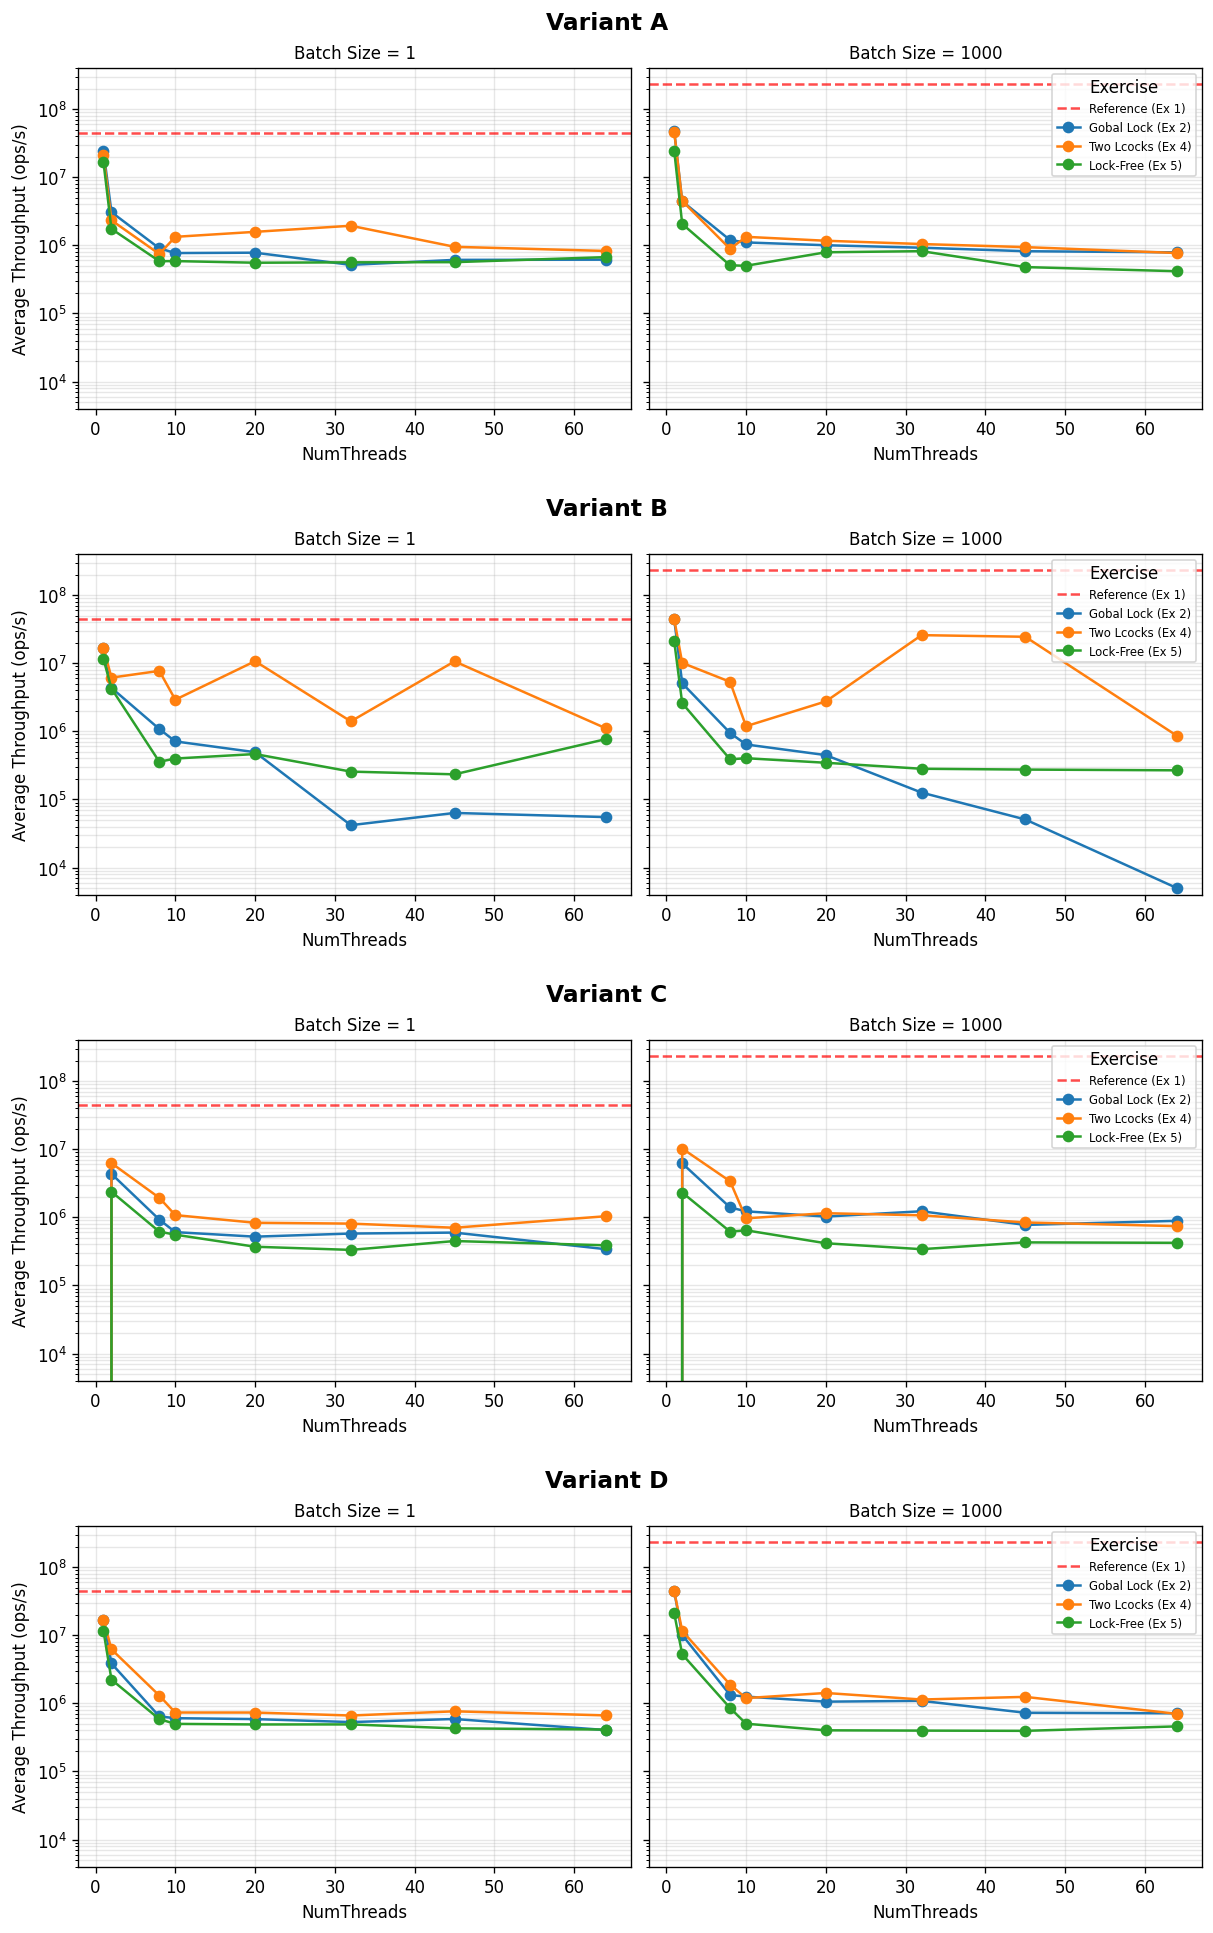

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'run_df' is your loaded DataFrame.
# df = pd.read_csv("your_data.csv") 

# ==========================================
# 1. PREPARE DATA
# ==========================================

# A. Prepare Main Data (Exercises 2, 3, 4, 5)
filtered_df = run_df[run_df["exercise"] != 1].copy()
agg_df = filtered_df.groupby(
    ["variant", "batch", "exercise", "NumThreads"], as_index=False
)["throughput_ops_s"].mean()

# B. Prepare Reference Data (Exercise 1)
# --- CHANGED: Filter for TimeInterval_s == 1 ONLY ---
ex1_df = run_df[(run_df["exercise"] == 1) & (run_df["TimeInterval_s"] == 1)].copy()
ref_agg = ex1_df.groupby(
    ["batch", "TimeInterval_s"], as_index=False
)["throughput_ops_s"].mean()

# ==========================================
# 2. PLOTTING
# ==========================================

# Create the Master Figure
fig = plt.figure(figsize=(10, 16), constrained_layout=True)

# Create 4 subfigures (4 rows, 1 column) for the Variants
subfigs = fig.subfigures(4, 1, wspace=0.05, hspace=0.05)

variants = sorted(agg_df['variant'].unique()) 
batches = [1, 1000]

legend_map = {
    2: "Gobal Lock (Ex 2)",
    4: "Two Lcocks (Ex 4)",
    5: "Lock-Free (Ex 5)",
}

for subfig, variant in zip(subfigs.flatten(), variants):
    
    subfig.suptitle(f"Variant {variant.upper()}", fontsize=14, fontweight='bold')
    
    # Create 1 row, 2 columns (Horizontal Split) for the batches
    axs = subfig.subplots(1, 2, sharey=True)
    
    for ax, batch in zip(axs, batches):
        # --- B. PLOT REFERENCE LINES (Exercise 1) ---
        ref_data = ref_agg[ref_agg['batch'] == batch]
        for _, row in ref_data.iterrows():
            val = row['throughput_ops_s']
            
            # Plot horizontal line (Style kept simple since only 1s exists now)
            ax.axhline(y=val, color='red', linestyle='--', alpha=0.7, 
                       label='Reference (Ex 1)')
            
        # --- A. PLOT MAIN EXERCISES (Curves) ---
        data = agg_df[(agg_df['variant'] == variant) & (agg_df['batch'] == batch)]
        
        for exercise in sorted(data['exercise'].unique()):
            ex_data = data[data['exercise'] == exercise]
            ax.plot(ex_data['NumThreads'], ex_data['throughput_ops_s'], 
                    marker='o', label=legend_map.get(exercise, f'Ex {exercise}'))

        # --- C. FORMATTING ---
        ax.set_title(f"Batch Size = {batch}", fontsize=10)
        ax.set_yscale("log")
        ax.grid(True, which="both", ls="-", alpha=0.3)
        ax.set_xlabel("NumThreads")
        
        # Consistent Y-Limits
        ax.set_ylim(4e3, 4e8) 
        
        # Y-Label: Only on the left plot
        if batch == 1:
            ax.set_ylabel("Average Throughput (ops/s)")

        # Legend: Only on the right plot
        if batch == 1000: 
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, title="Exercise", loc='upper right', fontsize='x-small')

plt.show()

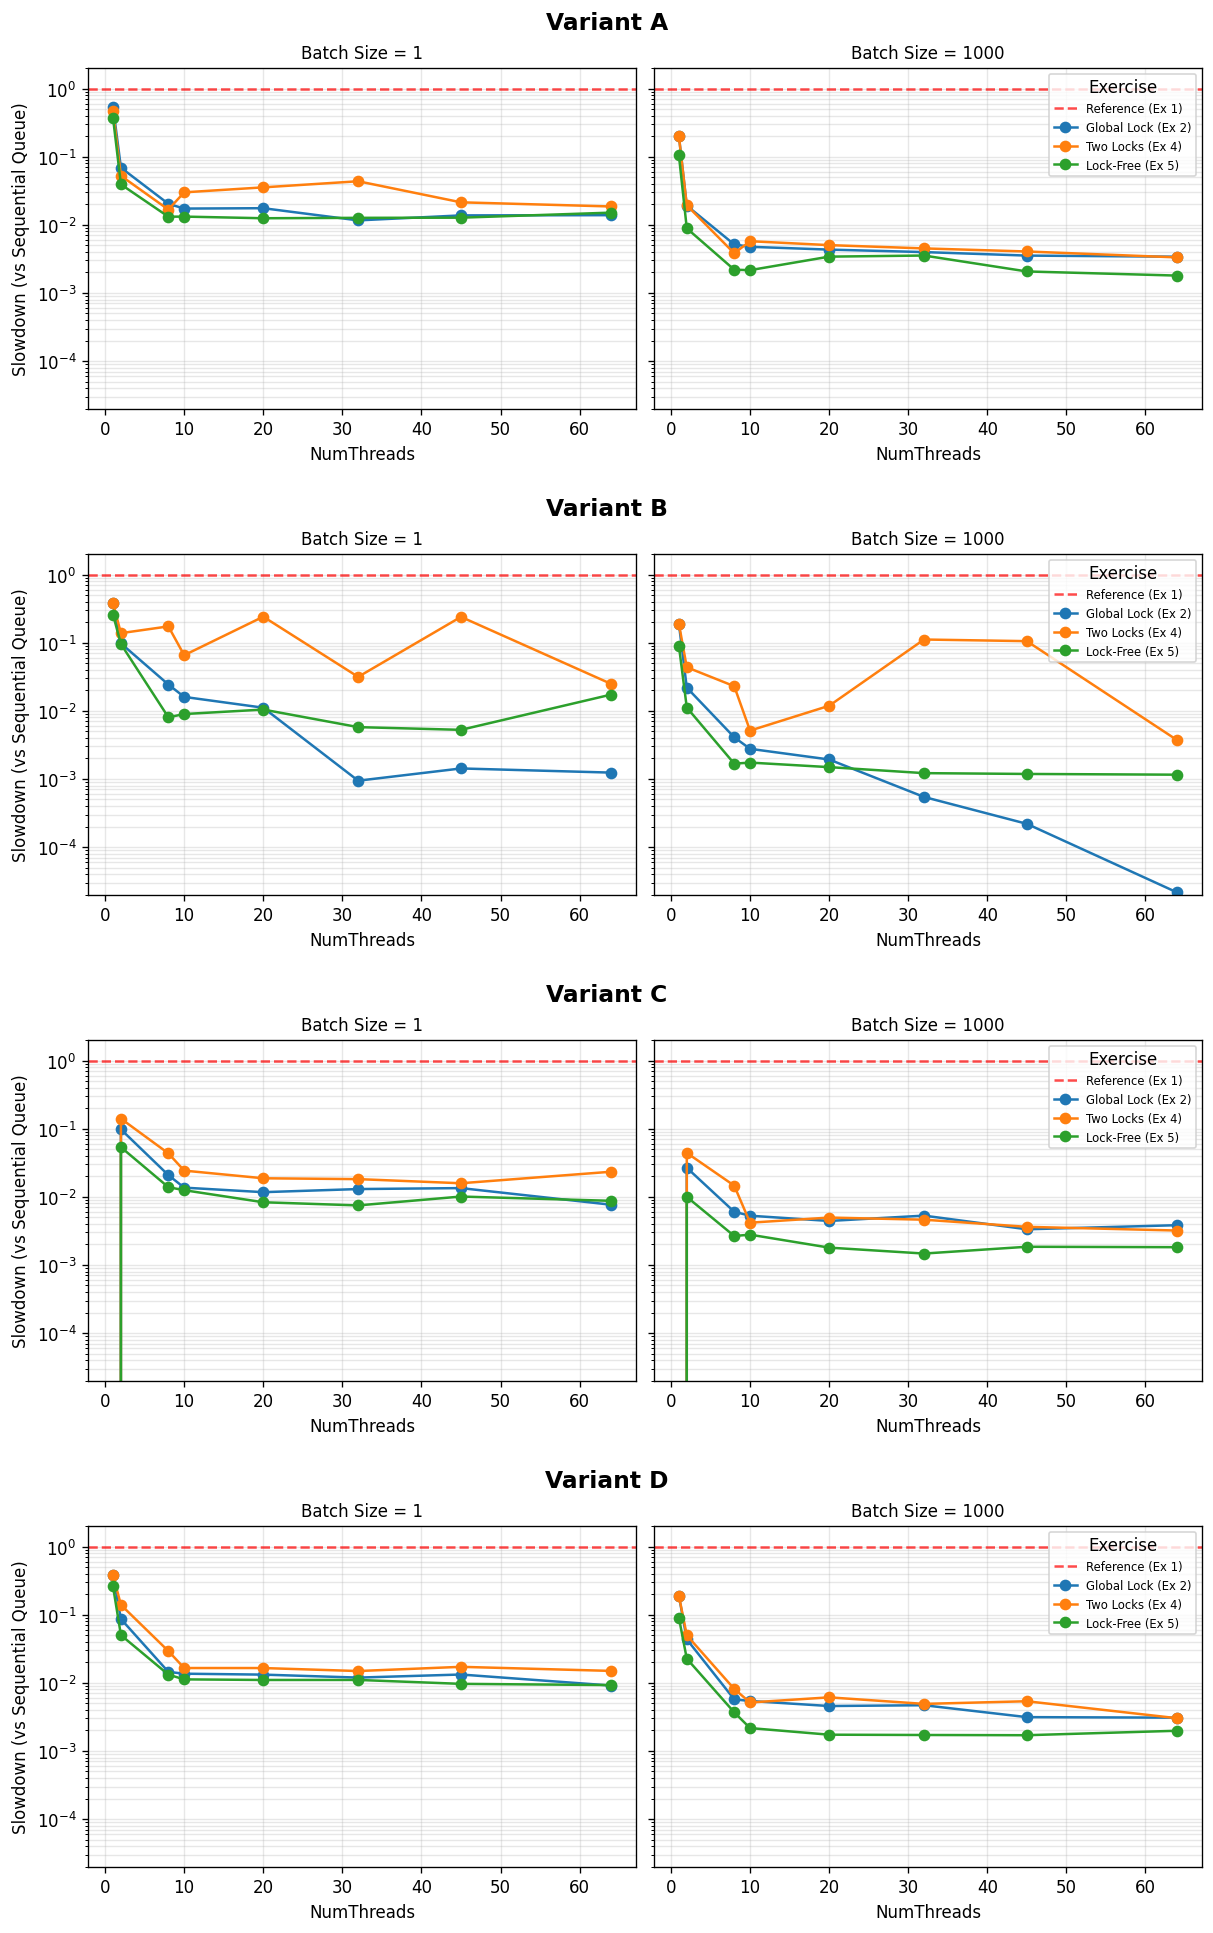

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'run_df' is your loaded DataFrame.
# df = pd.read_csv("your_data.csv") 

# ==========================================
# 1. PREPARE DATA (CALCULATE SPEEDUP)
# ==========================================

# A. Get Sequential Baselines (Exercise 1, 1 Thread) for each Batch
# We use Ex 1, 1 Thread as the baseline (speedup = 1.0)
seq_baseline = run_df[
    (run_df["exercise"] == 1) & 
    (run_df["NumThreads"] == 1)
].groupby("batch")["throughput_ops_s"].mean()

# B. Prepare Main Data (Exercises 2, 3, 4, 5)
filtered_df = run_df[run_df["exercise"] != 1].copy()
agg_df = filtered_df.groupby(
    ["variant", "batch", "exercise", "NumThreads"], as_index=False
)["throughput_ops_s"].mean()

# C. Calculate Speedup
# Speedup = throughput(p) / throughput(sequential_baseline_for_that_batch)
def calculate_speedup(row):
    baseline = seq_baseline.get(row['batch'], np.nan)
    if pd.isna(baseline) or baseline == 0:
        return np.nan
    return row['throughput_ops_s'] / baseline

agg_df['speedup'] = agg_df.apply(calculate_speedup, axis=1)

# ==========================================
# 2. PLOTTING
# ==========================================

# Create the Master Figure (EXACT STYLE REFERENCE)
fig = plt.figure(figsize=(10, 16), constrained_layout=True)

# Create 4 subfigures (4 rows, 1 column) for the Variants
subfigs = fig.subfigures(4, 1, wspace=0.05, hspace=0.05)

variants = sorted(agg_df['variant'].unique()) 
batches = [1, 1000]

legend_map = {
    2: "Global Lock (Ex 2)",
    4: "Two Locks (Ex 4)",
    5: "Lock-Free (Ex 5)",
}

for subfig, variant in zip(subfigs.flatten(), variants):
    
    # STYLE REF: Uppercase and Bold title
    subfig.suptitle(f"Variant {variant.upper()}", fontsize=14, fontweight='bold')
    
    # Create 1 row, 2 columns (Horizontal Split) for the batches
    axs = subfig.subplots(1, 2, sharey=True)
    
    for ax, batch in zip(axs, batches):
        # --- B. PLOT REFERENCE LINES (Exercise 1) ---
        # For Speedup, the reference (Ex 1) is always 1.0
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, 
                   label='Reference (Ex 1)')
            
        # --- A. PLOT MAIN EXERCISES (Curves) ---
        data = agg_df[(agg_df['variant'] == variant) & (agg_df['batch'] == batch)]
        
        for exercise in sorted(data['exercise'].unique()):
            ex_data = data[data['exercise'] == exercise]
            ax.plot(ex_data['NumThreads'], ex_data['speedup'], 
                    marker='o', label=legend_map.get(exercise, f'Ex {exercise}'))

        # --- C. FORMATTING ---
        # STYLE REF: Added "Size =" to title
        ax.set_title(f"Batch Size = {batch}", fontsize=10)
        ax.set_yscale("log")
        ax.grid(True, which="both", ls="-", alpha=0.3)
        ax.set_xlabel("NumThreads")
        
        # CHANGED: Y-Limits for Speedup/Slowdown
        # 1e-3 (0.001) to 2.0 covers severe slowdowns up to slight speedups
        ax.set_ylim(2e-5, 2) 
        
        # Y-Label: Only on the left plot
        if batch == 1:
            ax.set_ylabel("Slowdown (vs Sequential Queue)")

        # Legend: Only on the right plot
        if batch == 1000: 
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, title="Exercise", loc='upper right', fontsize='x-small')

plt.show()

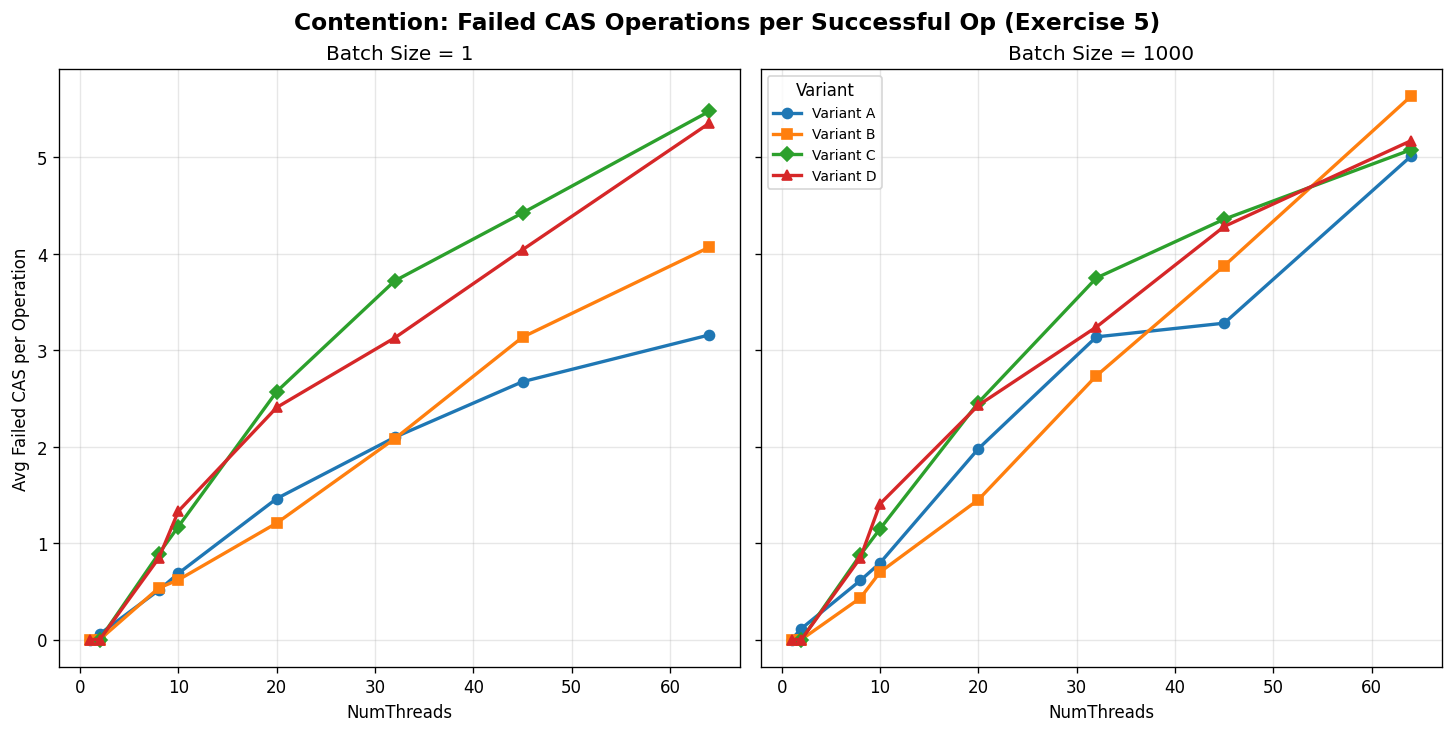

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'run_df' is your loaded DataFrame.
# df = pd.read_csv("your_data.csv") 

# ==========================================
# 1. PREPARE DATA (ONLY EXERCISE 5)
# ==========================================

# Filter only Exercise 5
ex5_df = run_df[run_df["exercise"] == 5].copy()

# Calculate the metric: (Failed Enq + Failed Deq) / Total Ops
# This represents the "wasted effort" per successful operation
ex5_df['failed_cas_sum'] = ex5_df['total_failed_enq_cas'] + ex5_df['total_failed_deq_cas']
ex5_df['cas_failure_ratio'] = ex5_df['failed_cas_sum'] / ex5_df['total_ops']

# Aggregate: Average over repetitions
agg_df = ex5_df.groupby(
    ["variant", "batch", "NumThreads"], as_index=False
)["cas_failure_ratio"].mean()

# ==========================================
# 2. PLOTTING
# ==========================================

# Create the Figure (1 Row, 2 Columns)
fig, axs = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True, sharey=True)
fig.suptitle("Contention: Failed CAS Operations per Successful Op (Exercise 5)", fontsize=14, fontweight='bold')

batches = [1, 1000]
variants = sorted(agg_df['variant'].unique())

for ax, batch in zip(axs, batches):
    
    # Filter for the current batch
    batch_data = agg_df[agg_df['batch'] == batch]
    
    # Plot each variant
    for variant in variants:
        data = batch_data[batch_data['variant'] == variant]
        
        # Skip if no data for this variant/batch combo
        if data.empty:
            continue
            
        style = style_map[variant]
        ax.plot(data['NumThreads'], data['cas_failure_ratio'], 
                label=f"Variant {variant.upper()}",
                marker=style['marker'],
                linewidth=2, markersize=6)

    # --- FORMATTING ---
    ax.set_title(f"Batch Size = {batch}", fontsize=12)
    
    # Linear Scale as requested
    ax.set_yscale("linear") 
    
    ax.grid(True, which="major", ls="-", alpha=0.3)
    ax.set_xlabel("NumThreads")
    
    # Y-Label: Only on the left plot
    if batch == 1:
        ax.set_ylabel("Avg Failed CAS per Operation")
    
    # Legend: Only on the right plot (or both if you prefer)
    if batch == 1000:
        ax.legend(title="Variant", fontsize='small')

plt.show()